# Fire Impact Assessment

## Table of Contents

1. [Import libraries](#1)<br>
2. [Read images](#2)<br>
3. [Subset](#3)<br>
    
</div>
<hr>

## 1. Import libraries

In [1]:
# Import necessary packages
import os

from shapely.geometry import mapping
# Use geopandas for vector data and xarray for raster data
import geopandas as gpd
import xarray as xr
import rioxarray as rxr

import earthpy as et
import earthpy.spatial as es
import earthpy.plot as ep

import hvplot.xarray # NO import as hv
import leafmap

import os
import sys
from glob import glob

import matplotlib.pyplot as plt
%matplotlib inline

C:\Users\Wenge\miniforge3\envs\sds\Lib\site-packages\earthpy\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


## 2. Open and read the polygon of the Jennings Creek Fire

## Read NYC temperature data

C:\Users\Wenge\Hunter College Dropbox\Wenge Ni-Meister\Teaching\GTECH\331&731\2025F_331&731\data\LC08_L2SP_013032_20220211_20220222_02_T1
C:\Users\Wenge\Hunter College Dropbox\Wenge Ni-Meister\Teaching\GTECH\331&731\2025F_331&731\data\LC08_L2SP_013032_20220211_20220222_02_T1\LC08_L2SP_013032_20220211_20220222_02_T1_ST_B10.TIF
EPSG:32618
1
7651
7781


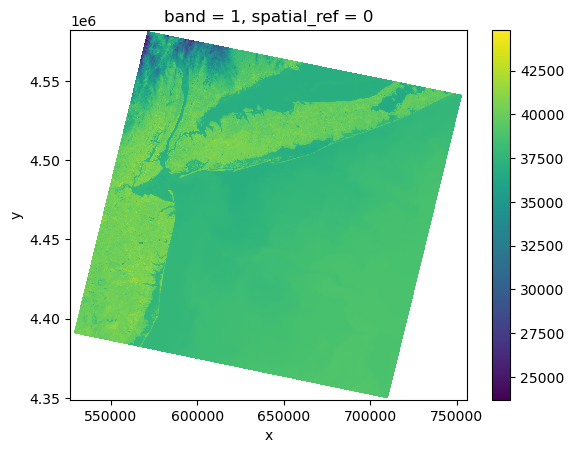

In [2]:
# need a NYC image
os.chdir(r'C:\Users\Wenge\Hunter College Dropbox\Wenge Ni-Meister\Teaching\GTECH\331&731\2025F_331&731\data\LC08_L2SP_013032_20220211_20220222_02_T1')
print(os.getcwd())
cwd = os.getcwd()
# Get all surface reflectance bands 
fp = glob(os.path.join(cwd,'*ST_B10*.tif'))
print(fp[0])
#print(fp[4])

tsurf = rxr.open_rasterio(fp[0], masked=True)
#red.rio.write_crs("EPSG:32618", inplace=True)

#tsurf_cl = tsurf.rio.clip(firepoly.geometry.apply(mapping), firepoly.crs )
tsurf.plot()

print(tsurf.rio.crs)
print(tsurf.rio.count)
print(tsurf.rio.width)
print(tsurf.rio.height)

In [5]:
#tsurf.hvplot.image()
m = leafmap.Map()
m.add_raster(tsurf, colormap="viridis")
m

Map(center=[40.320826499999995, -73.3163395], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…